In [ ]:
import pandas as pd
import numpy as np


path = ""


tables = {
    "orders": pd.read_csv(path + "olist_orders_dataset.csv"),
    "order_items": pd.read_csv(path + "olist_order_items_dataset.csv"),
    "products": pd.read_csv(path + "olist_products_dataset.csv"),
    "sellers": pd.read_csv(path + "olist_sellers_dataset.csv"),
    "customers": pd.read_csv(path + "olist_customers_dataset.csv"),
    "category_translation": pd.read_csv(path + "product_category_name_translation.csv")
}

# 2. Inspect shape, missing values, data types, and duplicates for each table
for name, df in tables.items():
    print(f"==================== Table: {name} ====================")
    print(f"Shape: {df.shape} (Rows, Columns)")
    print("\n--- Missing Values & Data Types ---")
    info_df = pd.DataFrame({
        'Data Type': df.dtypes,
        'Null Count': df.isnull().sum(),
        'Null Percentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
    })
    print(info_df)
    print(f"\nDuplicate Rows: {df.duplicated().sum()}")
    print("\n" + "="*50 + "\n")

==================== Table: orders ====================
Shape: (99441, 8) (Rows, Columns)

--- Missing Values & Data Types ---
                              Data Type  Null Count  Null Percentage (%)
order_id                         object           0                 0.00
customer_id                      object           0                 0.00
order_status                     object           0                 0.00
order_purchase_timestamp         object           0                 0.00
order_approved_at                object         160                 0.16
order_delivered_carrier_date     object        1783                 1.79
order_delivered_customer_date    object        2965                 2.98
order_estimated_delivery_date    object           0                 0.00

Duplicate Rows: 0


==================== Table: order_items ====================
Shape: (112650, 7) (Rows, Columns)

--- Missing Values & Data Types ---
                    Data Type  Null Count  Null Percentage (%)

In [ ]:
# Standardize date columns in orders dataset
orders = tables["orders"].copy()
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Handle missing values and translate product categories
products = tables["products"].copy()
category_translation = tables["category_translation"].copy()

# Merge English category translation
products = products.merge(category_translation, on='product_category_name', how='left')

# Impute missing category names with 'unknown'
products['product_category_name_english'] = products['product_category_name_english'].fillna('unknown')

# Verify Primary Key uniqueness
print("--- Primary Key Uniqueness Check ---")
print(f"Unique order_ids in orders: {orders['order_id'].nunique() == len(orders)}")
print(f"Unique product_ids in products: {products['product_id'].nunique() == len(products)}")
print(f"Unique seller_ids in sellers: {tables['sellers']['seller_id'].nunique() == len(tables['sellers'])}")

--- Primary Key Uniqueness Check ---
Unique order_ids in orders: True
Unique product_ids in products: True
Unique seller_ids in sellers: True


In [ ]:
# Check for negative or zero values in price and freight_value
order_items = tables["order_items"].copy()
invalid_prices = order_items[(order_items['price'] <= 0) | (order_items['freight_value'] < 0)]
print(f"Invalid prices or freight values found: {len(invalid_prices)}")

# Check for product weight/dimension anomalies (zero or negative values)
products = tables["products"].copy()
invalid_dimensions = products[
    (products['product_weight_g'] <= 0) |
    (products['product_length_cm'] <= 0) |
    (products['product_height_cm'] <= 0) |
    (products['product_width_cm'] <= 0)
]
print(f"Products with invalid dimensions or weight: {len(invalid_dimensions)}")

# Check Zip Code integrity in customers and sellers
customers = tables["customers"].copy()
sellers = tables["sellers"].copy()

print(f"Missing zip codes in customers: {customers['customer_zip_code_prefix'].isnull().sum()}")
print(f"Missing zip codes in sellers: {sellers['seller_zip_code_prefix'].isnull().sum()}")

Invalid prices or freight values found: 0
Products with invalid dimensions or weight: 4
Missing zip codes in customers: 0
Missing zip codes in sellers: 0


In [ ]:
# Identify delivered orders missing approval timestamps
delivered_no_approval = orders[(orders['order_status'] == 'delivered') & (orders['order_approved_at'].isnull())]
print(f"Delivered orders missing approval timestamp: {len(delivered_no_approval)}")

# Identify logical date anomalies (customer delivery prior to carrier dispatch)
date_anomalies = orders[orders['order_delivered_customer_date'] < orders['order_delivered_carrier_date']]
print(f"Orders with delivery date before carrier dispatch date (Anomalies): {len(date_anomalies)}")

# Filter clean, delivered orders for logistics pipeline analysis
clean_orders = orders[
    (orders['order_status'] == 'delivered') &
    (orders['order_delivered_customer_date'] >= orders['order_delivered_carrier_date']) &
    (orders['order_approved_at'].notnull())
].copy()

print(f"\nClean and valid orders ready for analysis: {len(clean_orders)} / {len(orders)}")

Delivered orders missing approval timestamp: 14
Orders with delivery date before carrier dispatch date (Anomalies): 23

Clean and valid orders ready for analysis: 96432 / 99441


In [ ]:
# Calculate supply chain lead time components in days
clean_orders['approval_days'] = (clean_orders['order_approved_at'] - clean_orders['order_purchase_timestamp']).dt.total_seconds() / 86400
clean_orders['seller_handling_days'] = (clean_orders['order_delivered_carrier_date'] - clean_orders['order_approved_at']).dt.total_seconds() / 86400
clean_orders['carrier_transit_days'] = (clean_orders['order_delivered_customer_date'] - clean_orders['order_delivered_carrier_date']).dt.total_seconds() / 86400
clean_orders['total_delivery_days'] = (clean_orders['order_delivered_customer_date'] - clean_orders['order_purchase_timestamp']).dt.total_seconds() / 86400

# Calculate delivery delay relative to estimated date
clean_orders['delay_days'] = (clean_orders['order_delivered_customer_date'] - clean_orders['order_estimated_delivery_date']).dt.total_seconds() / 86400
clean_orders['is_late'] = clean_orders['delay_days'] > 0

# Summary statistics for logistics metrics
print("--- Supply Chain Lead Times Summary (in Days) ---")
print(clean_orders[['seller_handling_days', 'carrier_transit_days', 'total_delivery_days', 'delay_days']].describe())

--- Supply Chain Lead Times Summary (in Days) ---
       seller_handling_days  carrier_transit_days  total_delivery_days  \
count          96432.000000          96432.000000         96432.000000   
mean               2.797416              9.333412            12.559055   
std                3.534703              8.759206             9.546411   
min             -171.219005              0.000000             0.533414   
25%                0.874141              4.101085             6.767121   
50%                1.815336              7.100156            10.217297   
75%                3.573406             12.030443            15.720906   
max              125.762569            205.190972           209.628611   

         delay_days  
count  96432.000000  
mean     -11.173791  
std       10.181562  
min     -146.016123  
25%      -16.242043  
50%      -11.940816  
75%       -6.387781  
max      188.975081  


In [ ]:
# 1. Filter out logical errors (negative seller handling time)
valid_lead_times = clean_orders[clean_orders['seller_handling_days'] >= 0].copy()

# 2. Filter out extreme system outliers (e.g., transit/handling > 99th percentile)
seller_99th = valid_lead_times['seller_handling_days'].quantile(0.99)
carrier_99th = valid_lead_times['carrier_transit_days'].quantile(0.99)

filtered_logistics = valid_lead_times[
    (valid_lead_times['seller_handling_days'] <= seller_99th) &
    (valid_lead_times['carrier_transit_days'] <= carrier_99th)
].copy()

print(f"Valid orders remaining after filtering lead time anomalies: {len(filtered_logistics)} / {len(clean_orders)}")
print("\n--- Corrected Supply Chain Lead Times Summary (in Days) ---")
print(filtered_logistics[['seller_handling_days', 'carrier_transit_days', 'total_delivery_days', 'delay_days']].describe())

Valid orders remaining after filtering lead time anomalies: 93193 / 96432

--- Corrected Supply Chain Lead Times Summary (in Days) ---
       seller_handling_days  carrier_transit_days  total_delivery_days  \
count          93193.000000          93193.000000         93193.000000   
mean               2.628538              8.880077            11.909854   
std                2.558770              6.902055             7.498833   
min                0.000174              0.000000             0.533414   
25%                0.893148              4.088565             6.731991   
50%                1.822650              7.082234            10.136956   
75%                3.522546             11.925440            15.228681   
max               17.138773             41.024282            56.117072   

         delay_days  
count  93193.000000  
mean     -11.679439  
std        8.666334  
min     -146.016123  
25%      -16.264641  
50%      -12.044711  
75%       -6.971030  
max       32.985081  


In [ ]:
# Merge filtered clean orders with order_items, sellers, and customers
merged_df = filtered_logistics.merge(tables["order_items"], on='order_id', how='inner')
merged_df = merged_df.merge(tables["sellers"], on='seller_id', how='inner')
merged_df = merged_df.merge(tables["customers"], on='customer_id', how='inner')

# Aggregate seller-level SLA performance metrics
seller_performance = merged_df.groupby('seller_id').agg(
    total_orders=('order_id', 'nunique'),
    avg_seller_handling_days=('seller_handling_days', 'mean'),
    avg_carrier_transit_days=('carrier_transit_days', 'mean'),
    late_orders_count=('is_late', 'sum'),
    late_rate=('is_late', 'mean')
).reset_index()

# Filter active sellers (at least 10 orders) and sort by delay rate
active_sellers = seller_performance[seller_performance['total_orders'] >= 10].sort_values(by='late_rate', ascending=False)

print("--- Top 10 Sellers with Highest Delay Rates ---")
print(active_sellers.head(10))

--- Top 10 Sellers with Highest Delay Rates ---
                             seller_id  total_orders  \
441   2709af9587499e95e803a6498a5a56e9            25   
2236  c37b2059d4f90d4feead554e5246565e            12   
1525  821fb029fc6e495ca4f08a35d51e53a5            22   
2727  ede0c03645598cdfc63ca8237acbe73d            43   
29    02d35243ea2e497335cd0f076b45675d            13   
2634  e64d65bc8dbec2accda90c58de5d1246            12   
1065  5b581417df4480f632484ba681e53944            11   
2833  f76a3b1349b6df1ee875d1f3fa4340f0            21   
211   13074f016982ff2bd6c58ced8682f000            13   
30    02dcd3e8e25bee036e32512bcf175493            12   

      avg_seller_handling_days  avg_carrier_transit_days  late_orders_count  \
441                   2.362330                  9.648805                 23   
2236                  7.983938                 11.127131                  7   
1525                  1.698456                 13.435289                  8   
2727               

In [8]:
# Define SLA thresholds (e.g., 3 days max for seller handling)
SLA_SELLER_LIMIT_DAYS = 3.0

# Filter only late orders
late_orders = merged_df[merged_df['is_late'] == True].copy()

# Classify root cause of delay
def classify_delay_cause(row):
    seller_fault = row['seller_handling_days'] > SLA_SELLER_LIMIT_DAYS
    # If seller took > 3 days, seller contributed to delay
    if seller_fault:
        return 'Seller Bottleneck (SLA Exceeded)'
    else:
        return 'Carrier / Route Bottleneck'

late_orders['delay_root_cause'] = late_orders.apply(classify_delay_cause, axis=1)

print("--- Root Cause Analysis for Late Orders ---")
print(late_orders['delay_root_cause'].value_counts(normalize=True) * 100)

--- Root Cause Analysis for Late Orders ---
delay_root_cause
Carrier / Route Bottleneck          50.598507
Seller Bottleneck (SLA Exceeded)    49.401493
Name: proportion, dtype: float64


In [9]:
# Analyze carrier transit time and delay rate by Seller State -> Customer State routes
route_performance = merged_df.groupby(['seller_state', 'customer_state']).agg(
    total_orders=('order_id', 'nunique'),
    avg_carrier_transit_days=('carrier_transit_days', 'mean'),
    late_rate=('is_late', 'mean')
).reset_index()

# Filter high-volume routes (at least 50 orders) and sort by delay rate
top_delayed_routes = route_performance[route_performance['total_orders'] >= 50].sort_values(by='late_rate', ascending=False)

print("--- Top 10 High-Volume Logistics Routes with Highest Delay Rates ---")
print(top_delayed_routes.head(10))

--- Top 10 High-Volume Logistics Routes with Highest Delay Rates ---
    seller_state customer_state  total_orders  avg_carrier_transit_days  \
381           SP             AL           238                 19.677590   
137           MA             SP           109                 10.501223   
389           SP             MA           461                 17.647439   
280           RJ             CE            51                 18.041338   
148           MG             MA            63                 15.824453   
396           SP             PI           312                 15.216357   
404           SP             SE           194                 15.936118   
384           SP             BA          2217                 15.477692   
387           SP             ES          1422                 11.827034   
391           SP             MS           466                 12.295255   

     late_rate  
381   0.207843  
137   0.205357  
389   0.204280  
280   0.176471  
148   0.166667  
396

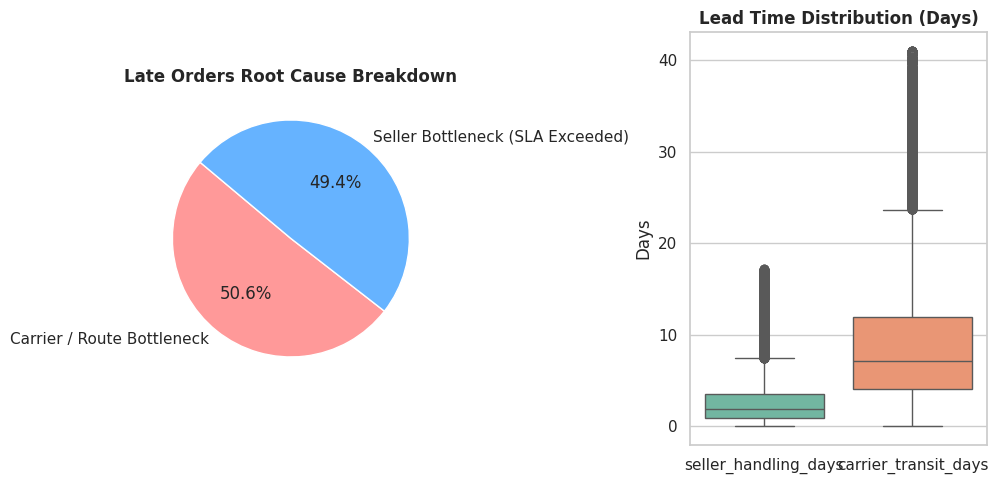

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# Plot 1: Delay Cause Breakdown
plt.subplot(1, 2, 1)
cause_counts = late_orders['delay_root_cause'].value_counts()
colors = ['#ff9999', '#66b3ff']
plt.pie(cause_counts, labels=cause_counts.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Late Orders Root Cause Breakdown', fontsize=12, fontweight='bold')

# Plot 2: Seller Handling vs Carrier Transit Distribution
plt.subplot(1, 2, 2)
sns.boxplot(data=filtered_logistics[['seller_handling_days', 'carrier_transit_days']], palette="Set2")
plt.title('Lead Time Distribution (Days)', fontsize=12, fontweight='bold')
plt.ylabel('Days')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1101/1126421342.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_delayed_routes.head(8), x='late_rate', y='route', palette='Reds_r')


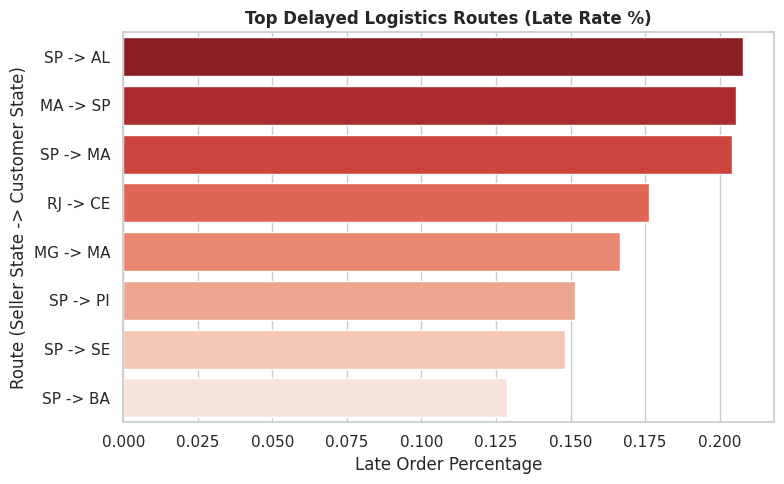

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Top Delayed Logistics Routes Bar Chart
top_delayed_routes['route'] = top_delayed_routes['seller_state'] + ' -> ' + top_delayed_routes['customer_state']
sns.barplot(data=top_delayed_routes.head(8), x='late_rate', y='route', palette='Reds_r')

plt.title('Top Delayed Logistics Routes (Late Rate %)', fontsize=12, fontweight='bold')
plt.xlabel('Late Order Percentage')
plt.ylabel('Route (Seller State -> Customer State)')

plt.tight_layout()
plt.show()

In [12]:
# Cell 10: HVIA Solutions Impact & Value Quantification
total_late_orders = len(late_orders)
seller_late_orders = len(late_orders[late_orders['delay_root_cause'] == 'Seller Bottleneck (SLA Exceeded)'])
carrier_late_orders = len(late_orders[late_orders['delay_root_cause'] == 'Carrier / Route Bottleneck'])

print("=========================================================================")
print("                   HVIA STRATEGIC IMPACT SUMMARY                         ")
print("=========================================================================")
print(f"Total Analyzed Delivered Orders : {len(filtered_logistics):,}")
print(f"Total Late Deliveries Identified : {total_late_orders:,} ({total_late_orders / len(filtered_logistics) * 100:.2f}% late rate)")
print(f"  └─ Solvable by Seller SLA Automation : {seller_late_orders:,} orders ({seller_late_orders / total_late_orders * 100:.1f}%)")
print(f"  └─ Solvable by Dynamic Route/Regional Fulfillment : {carrier_late_orders:,} orders ({carrier_late_orders / total_late_orders * 100:.1f}%)")
print("=========================================================================")

                   HVIA STRATEGIC IMPACT SUMMARY                         
Total Analyzed Delivered Orders : 93,193
Total Late Deliveries Identified : 7,101 (7.62% late rate)
  └─ Solvable by Seller SLA Automation : 3,508 orders (49.4%)
  └─ Solvable by Dynamic Route/Regional Fulfillment : 3,593 orders (50.6%)
